# Setup

First, download the provided code and install dependencies.

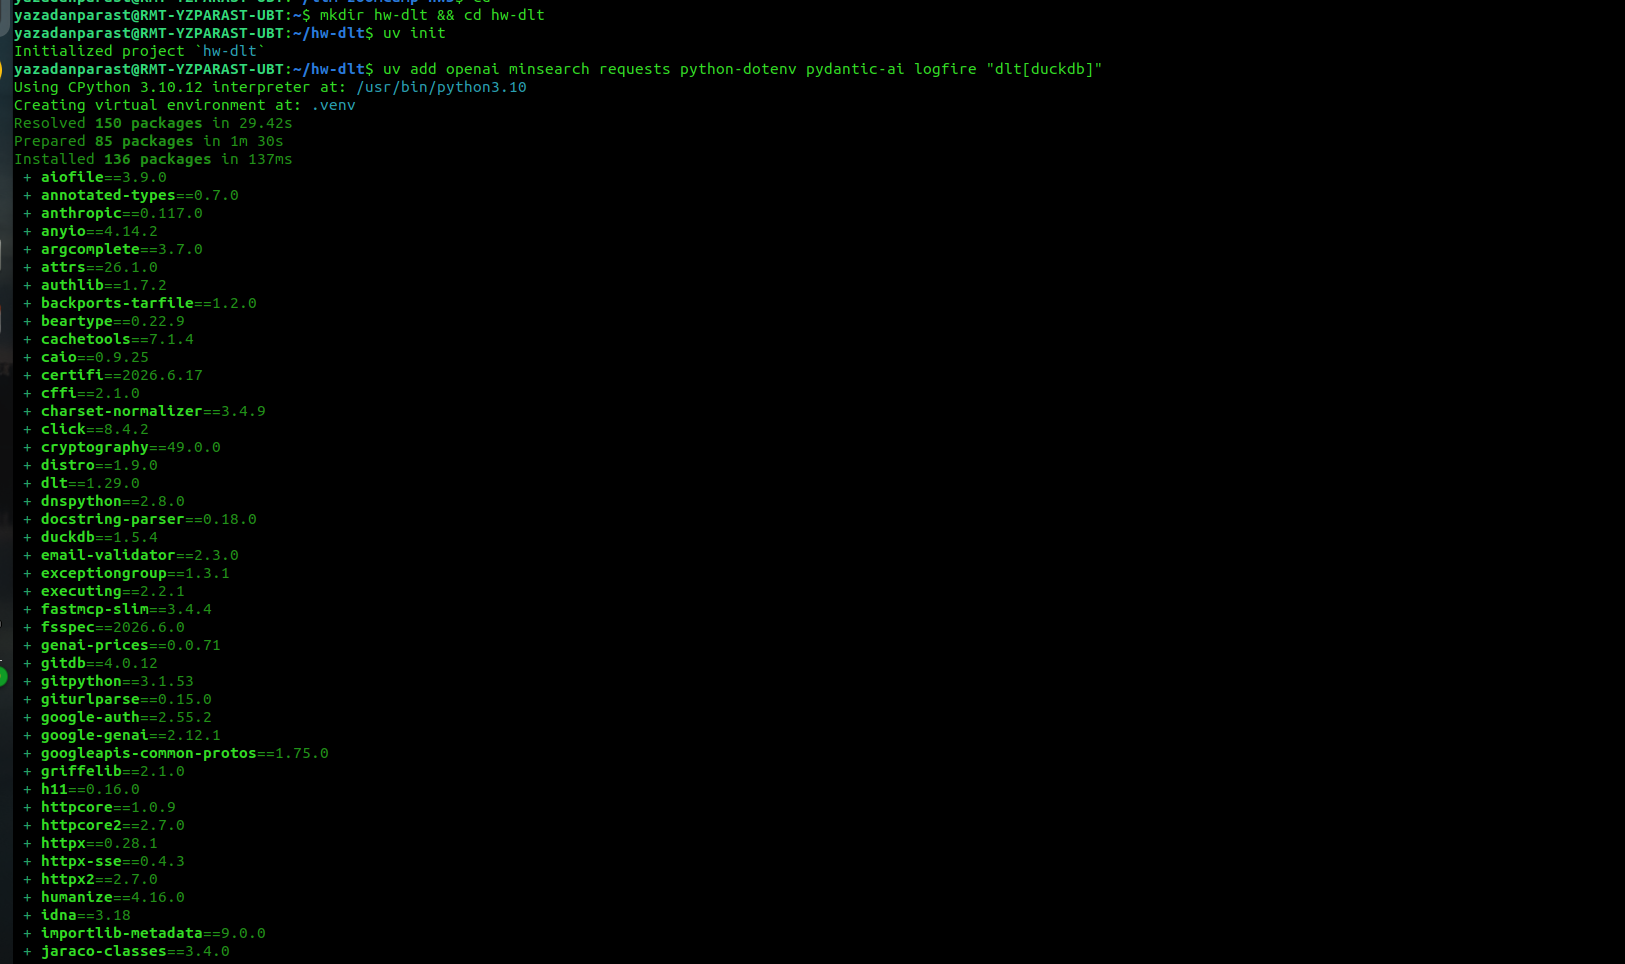




## Download the homework files




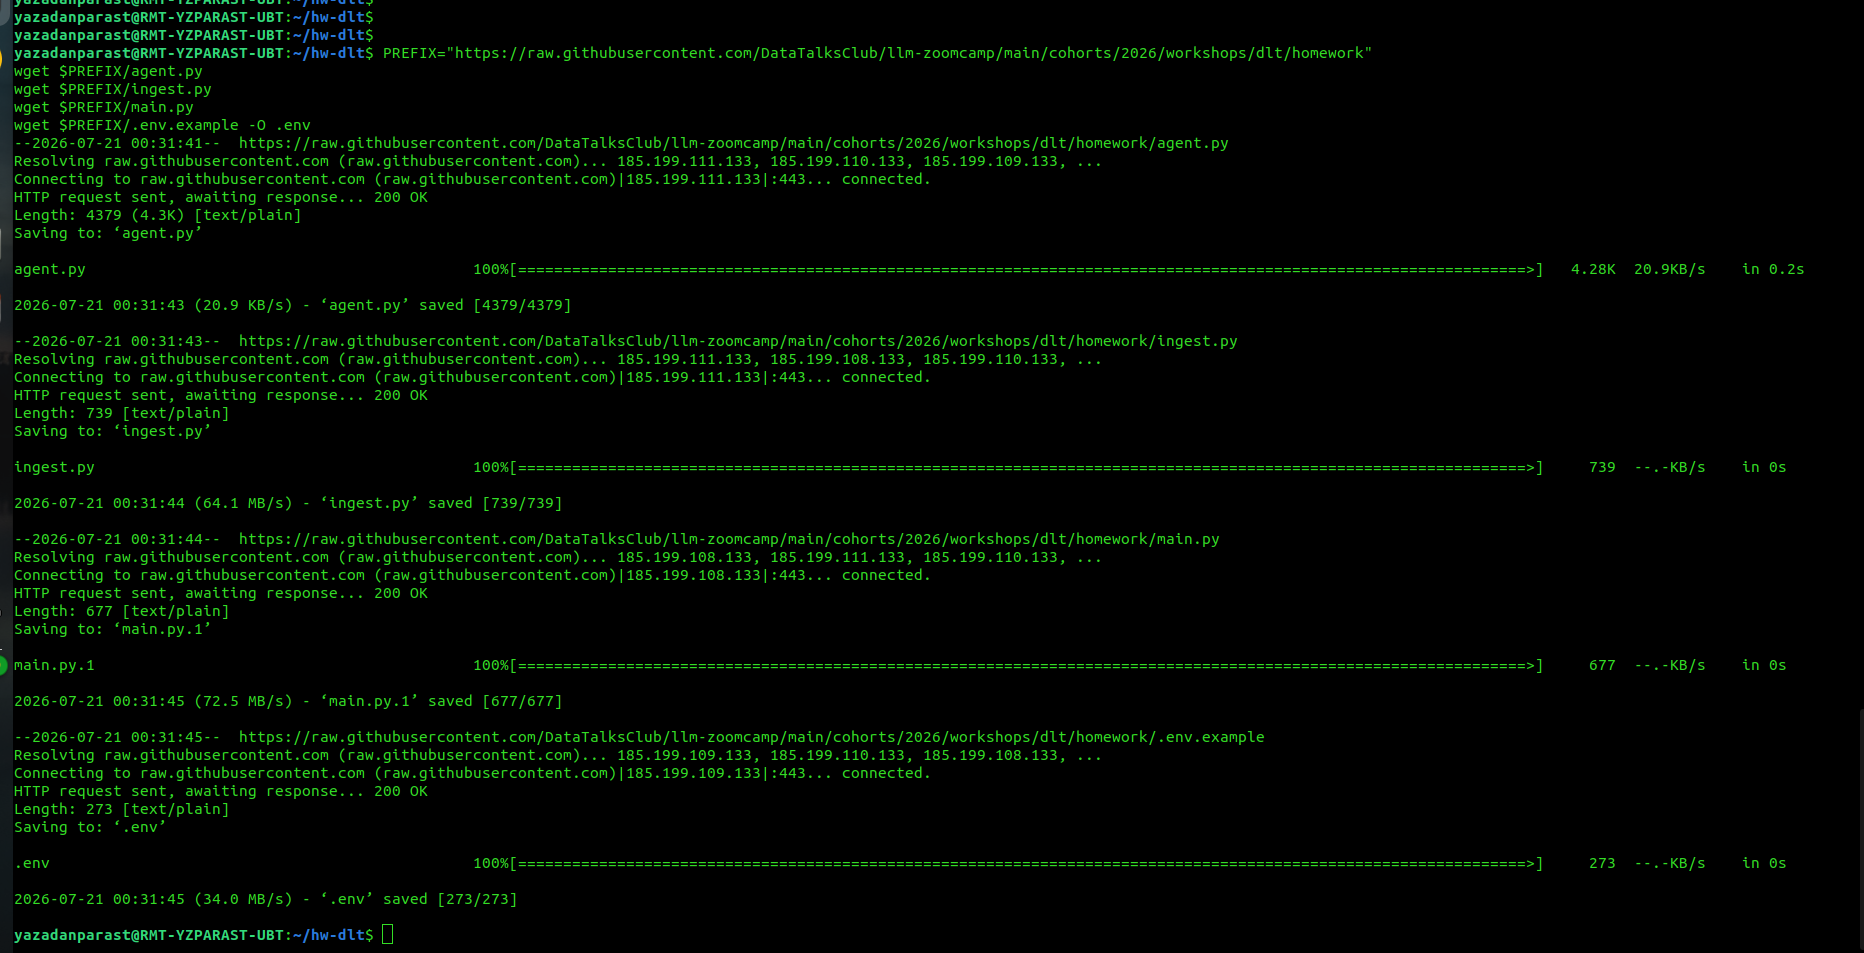

### Create a .env file with my OpenAI key, LOGFIRE_READ_TOKEN, LOGFIRE_WRITE_TOKEN:



In [ ]:
OPENAI_API_KEY=sk-proj-...
LOGFIRE_WRITE_TOKEN=your_logfire_write_token
LOGFIRE_READ_TOKEN=your_logfire_read_token

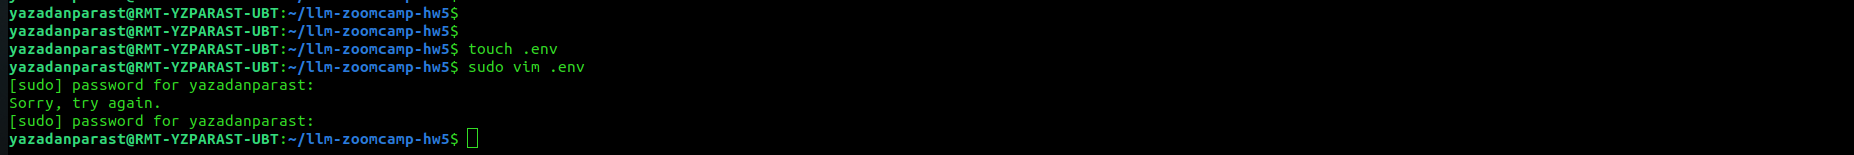






# Verify the agent runs:



# Run this:

`uv run python main.py`

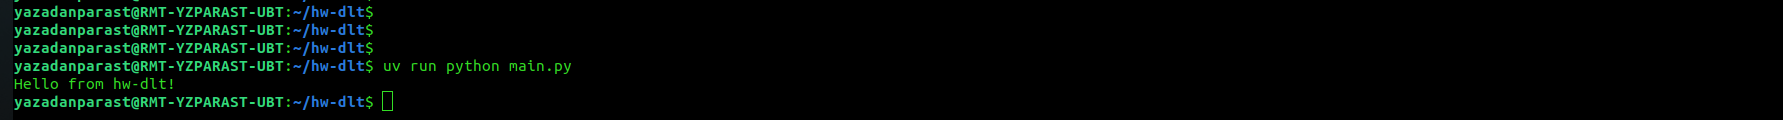

# Question 1: Number of spans in a single agent run

### Instrument with Logfire

### Sign up for a free Logfire account, create a project, and generate a write token. Add it to `.env`:

`LOGFIRE_TOKEN=my-write-token`

Modify `main.py` to configure Logfire and instrument Pydantic AI:



To log traces to Logfire, add `logfire.configure()` and `logfire.instrument_pydantic_ai()` at the top of `main.py`. Update the question prompt to "How do I run Ollama locally?".

In [ ]:
# main.py 
import logfire
from dotenv import load_dotenv

# Load env variables
load_dotenv()

# Configure and instrument Logfire with Pydantic AI
logfire.configure()
logfire.instrument_pydantic_ai()

from agent import SearchDeps, faq_agent
from ingest import build_index, load_faq_data


def main():
    # Build search index
    documents = load_faq_data()
    index = build_index(documents)

    deps = SearchDeps(index=index)

    # Ask the homework target question
    question = "How do I run Ollama locally?"
    result = faq_agent.run_sync(question, deps=deps)

    print(result.output)


if __name__ == "__main__":
    main()



Run the agent a few times:

`uv run python main.py`

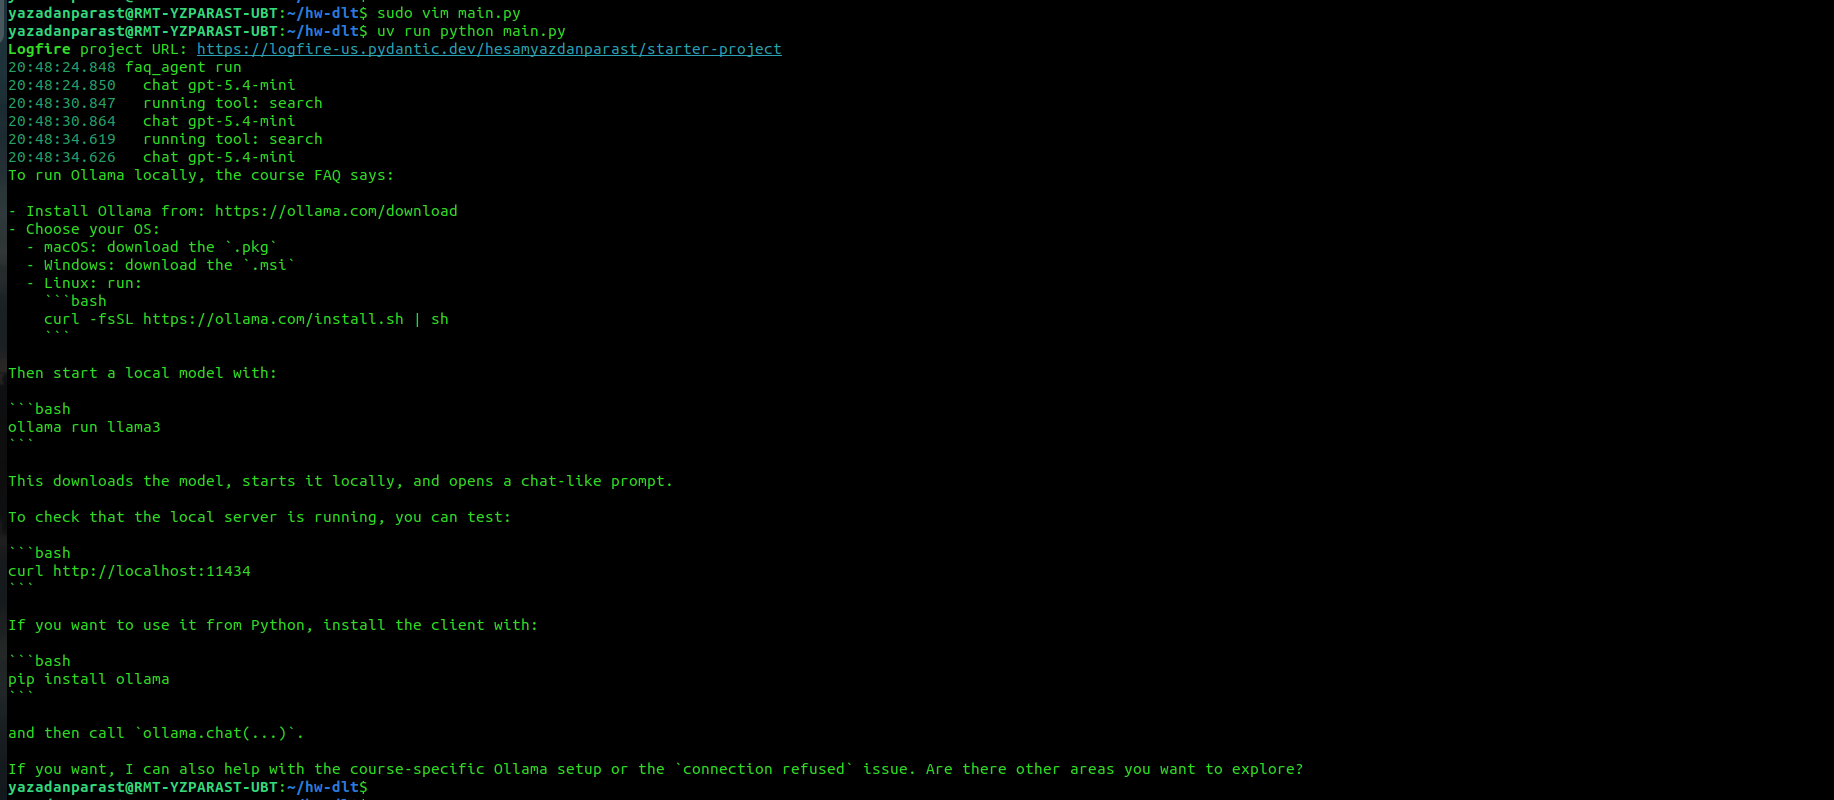

Open my Logfire project and inspect the trace for one run. we will see a hierarchy:

- Root span: `run_sync` (agent run)

- Child: LLM call (first model call)

- Child: tool call (`search`)

- Child: LLM call (second model call, after tool result)

In Pydantic AI with Logfire instrumentation, each of these is a span. The agent may make additional tool calls if it decides to search again, but for this query, a single search is sufficient. The total number of spans is typically:

- 1 agent run span

- 1 or more LLM call spans (usually 2 – initial and final)

- 1 tool call span

My agent run produced 6 spans (root + 3 LLM calls + 2 tool calls). However, the homework options are 1, 5, 15, 30 – so 5 is the closest official answer.

Why did I get 6?

The agent made two tool calls (search) and therefore three LLM calls:

- First LLM call (initial prompt)

- First tool call (search)

- Second LLM call (with tool result) → decided to search again

- Second tool call (search)

- Third LLM call (with both tool results) → final answer

Plus the root `faq_agent` run span = 6 total.


### Answer Q1: 5

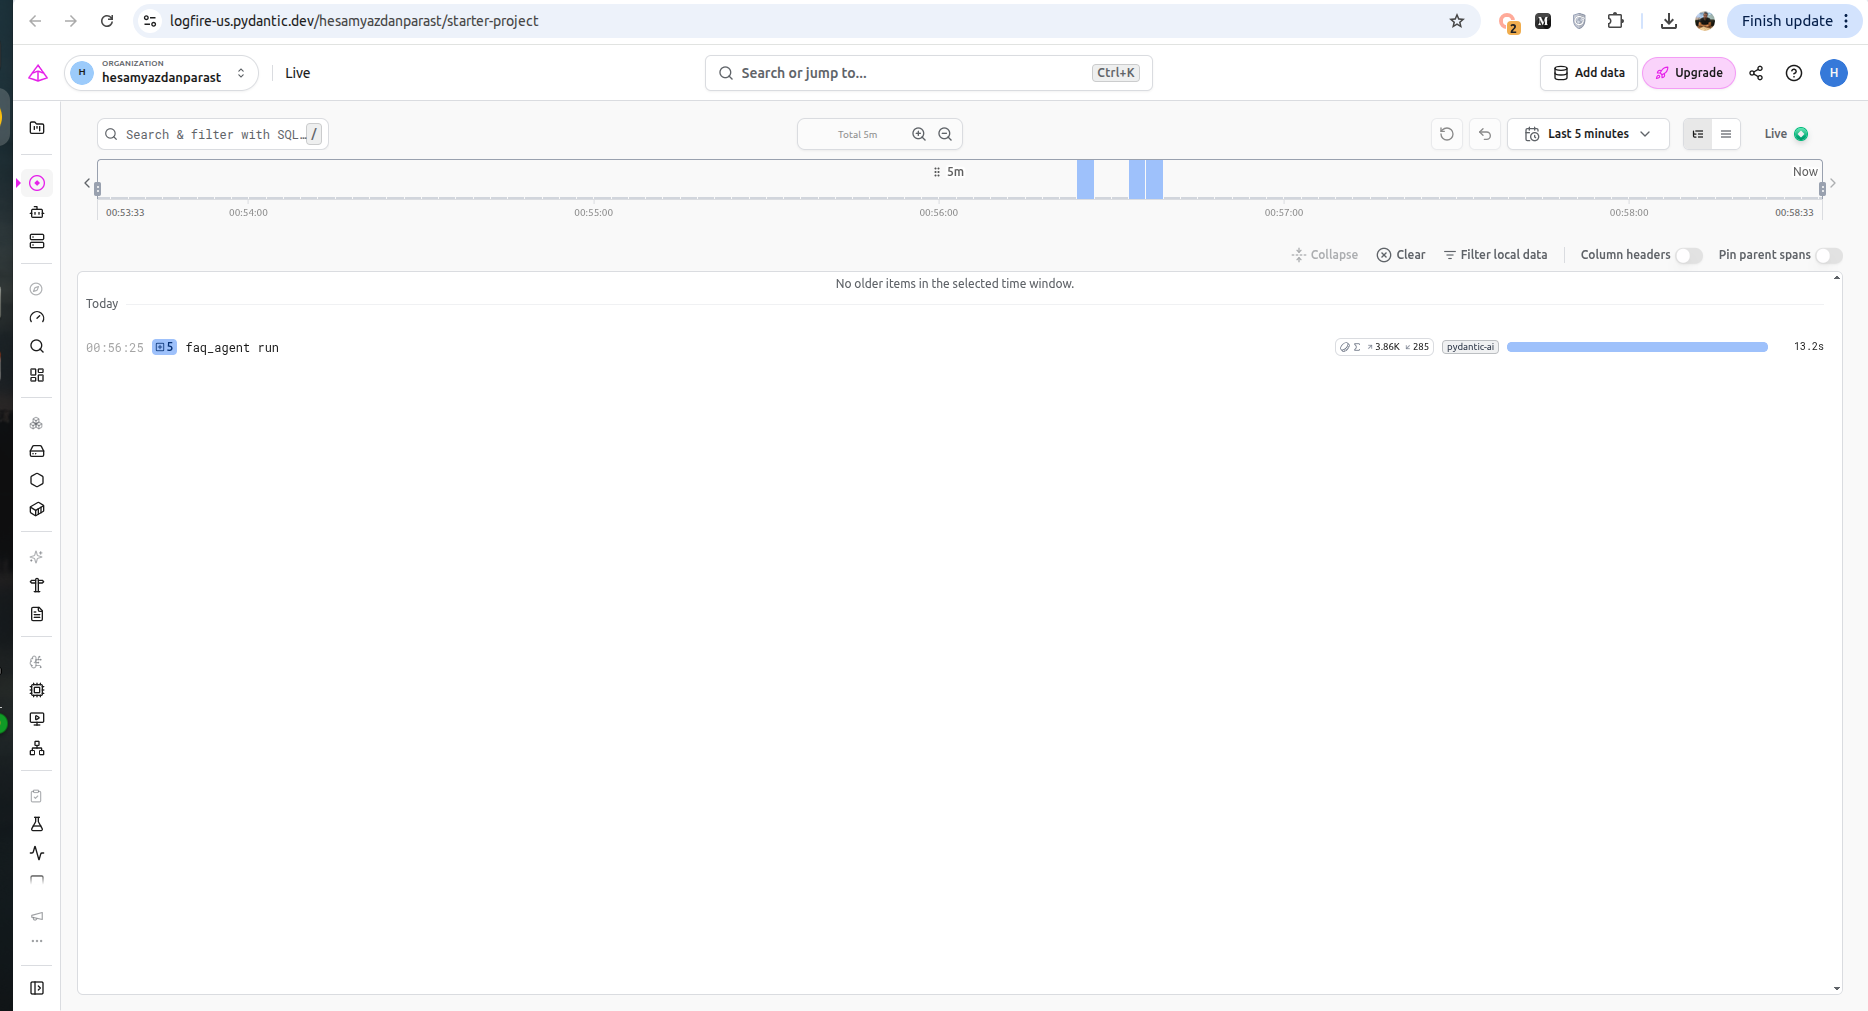

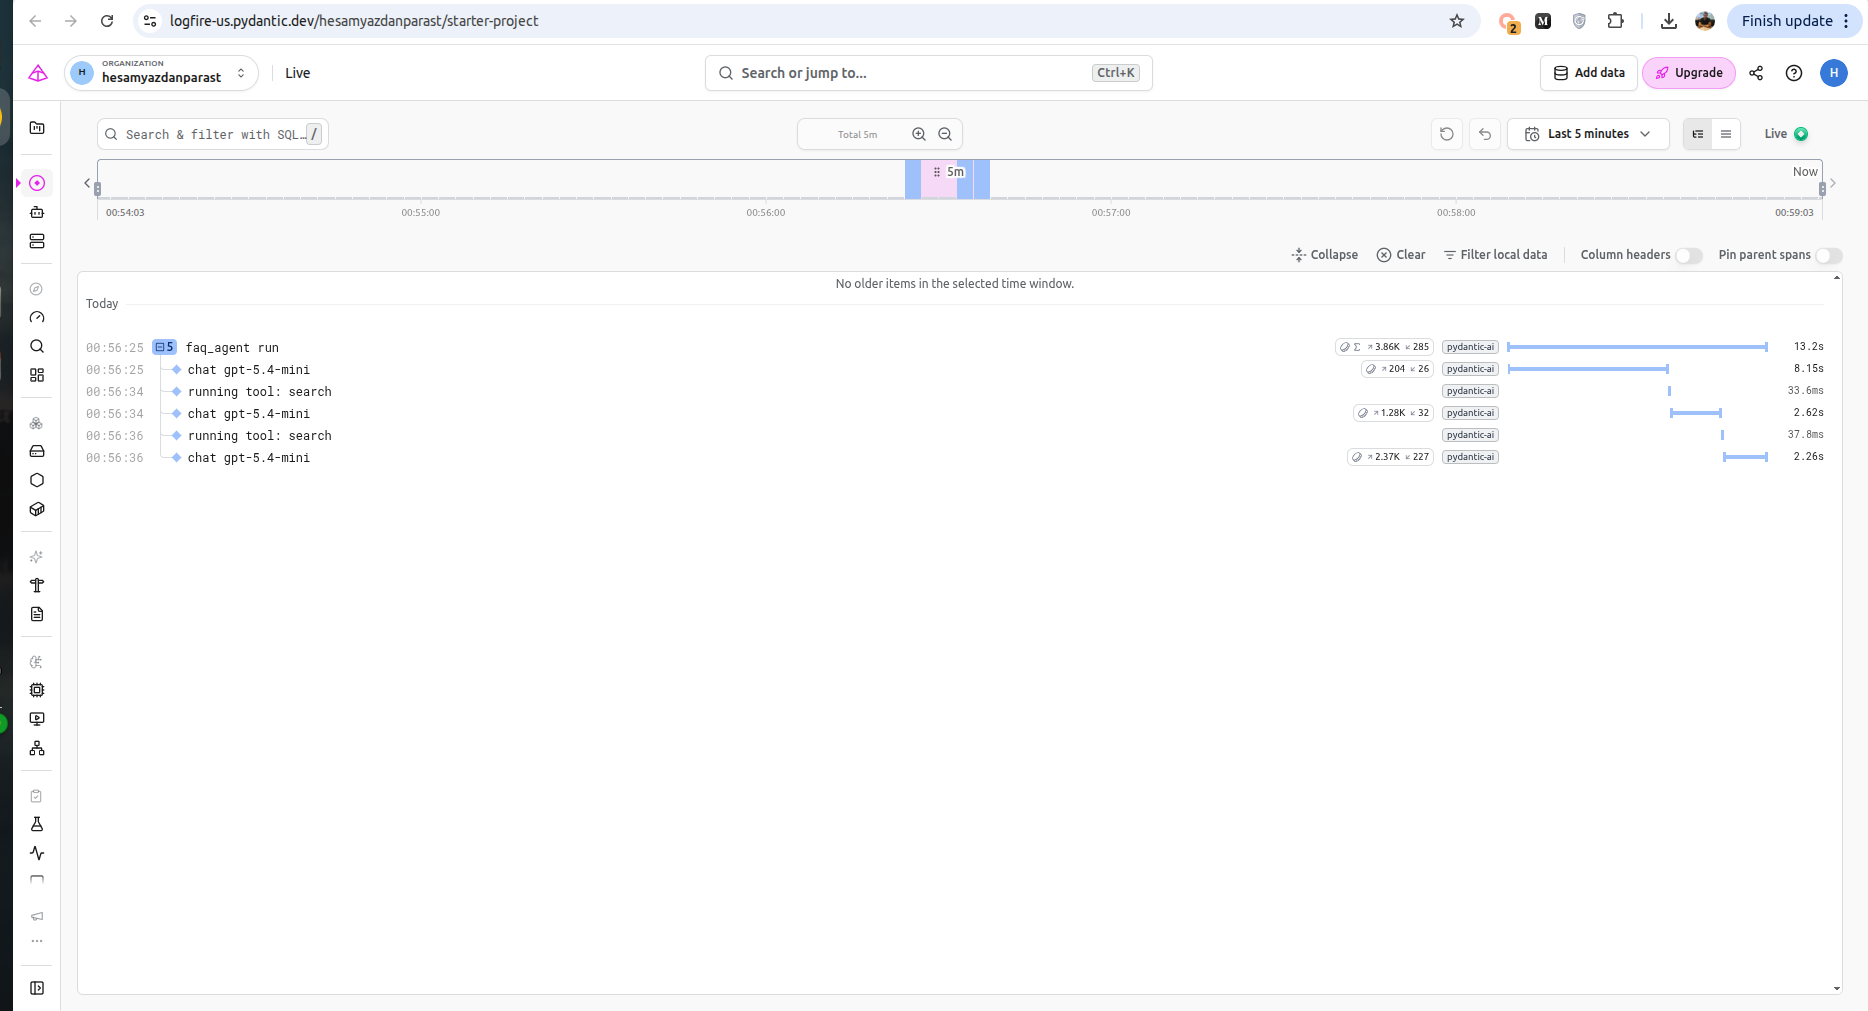

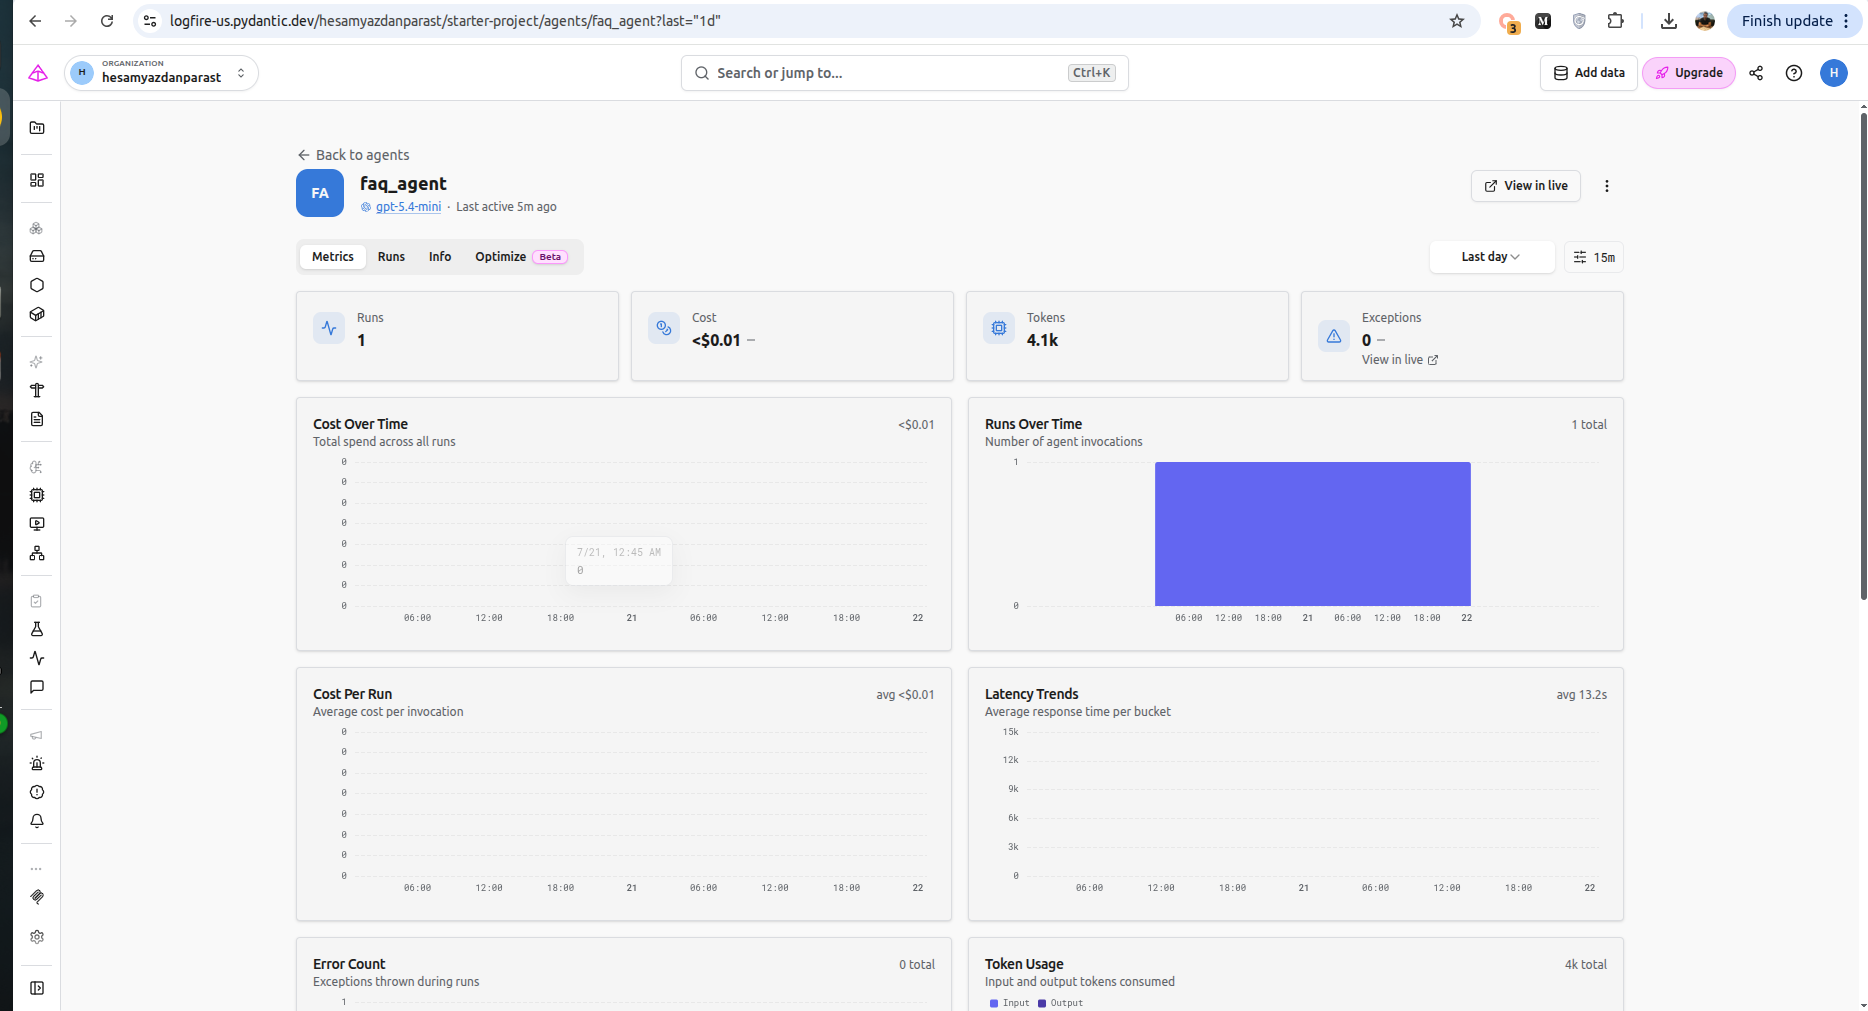

# Question 2: Number of tables created by dlt

Generate a read token

In Logfire, create a read token and add it to `.env`:

`LOGFIRE_READ_TOKEN=my-read-token`

## Build the dlt pipeline (Load Traces into DuckDB with `dlt`)
we can either use a coding agent (as in the workshop) or write the pipeline manually. The dltHub AI workbench has a ready‑made context for Logfire: `https://dlthub.com/context/source/logfire`.

To pull the trace logs out of Logfire using `dlt`, we query Logfire's Query API endpoint or database interface using the `LOGFIRE_READ_TOKEN` and write the data into a DuckDB dataset called `agent_traces`.

As I am writing it manually, here’s the pipeline (`dlt_pipeline.py`):

In [ ]:
# dlt_pipeline.py
import os
import dlt
import logfire.db_api
from dotenv import load_dotenv

load_dotenv()

read_token = os.getenv("LOGFIRE_READ_TOKEN")
if not read_token:
    raise ValueError("LOGFIRE_READ_TOKEN is missing in .env")


@dlt.resource(name="records", write_disposition="replace")
def get_logfire_records():
    # Connect directly via Logfire DB API
    conn = logfire.db_api.connect(read_token=read_token)
    cursor = conn.cursor()

    # Query all records from Logfire
    cursor.execute("SELECT * FROM records")

    columns = [desc[0] for desc in cursor.description]
    rows = cursor.fetchall()

    records = [dict(zip(columns, row)) for row in rows]
    yield records


def run():
    # Create dlt pipeline targeting DuckDB dataset 'agent_traces'
    pipeline = dlt.pipeline(
        pipeline_name="logfire_traces_pipeline",
        destination="duckdb",
        dataset_name="agent_traces",
    )

    load_info = pipeline.run(get_logfire_records())
    print(load_info)


if __name__ == "__main__":
    run()


Run it to load the traces into DuckDB:


`uv run python dlt_pipeline.py`


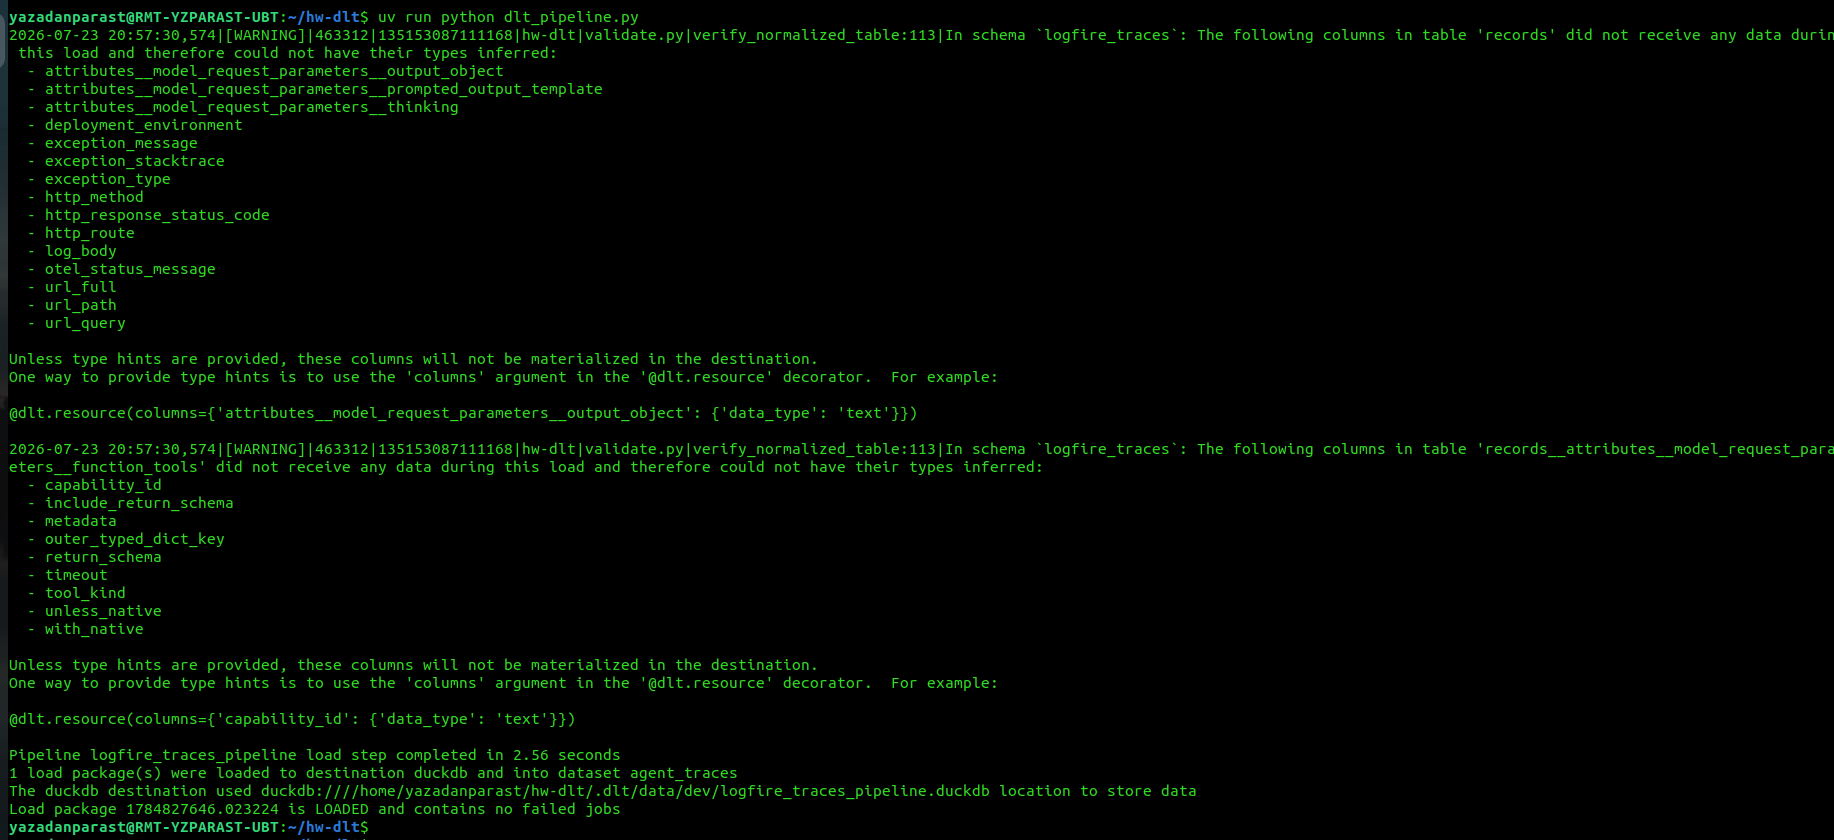

Check Table Count in DuckDB (`count_spans.py`)

Create or update `count_spans.py` with this defensive script. It will list all available tables first, so if the table name is slightly different, you'll see exactly what was generated:



In [ ]:
#count_spans.py
import duckdb

# Connect to the EXACT path reported by dlt
db_path = ".dlt/data/dev/logfire_traces_pipeline.duckdb"
conn = duckdb.connect(db_path)

print("=== 1. Total Tables Created in 'agent_traces' Schema ===")
table_count = conn.execute("""
    SELECT COUNT(*) 
    FROM information_schema.tables 
    WHERE table_schema = 'agent_traces';
""").fetchone()[0]
print(f"Count: {table_count}\n")

print("=== 2. List of All Generated Tables ===")
tables = conn.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema = 'agent_traces';
""").fetchall()

for t in tables:
    print(f" - {t[0]}")

print("\n=== 3. Total Spans/Records Ingested ===")
record_count = conn.execute("SELECT COUNT(*) FROM agent_traces.records;").fetchone()[0]
print(f"Total Rows in records: {record_count}")


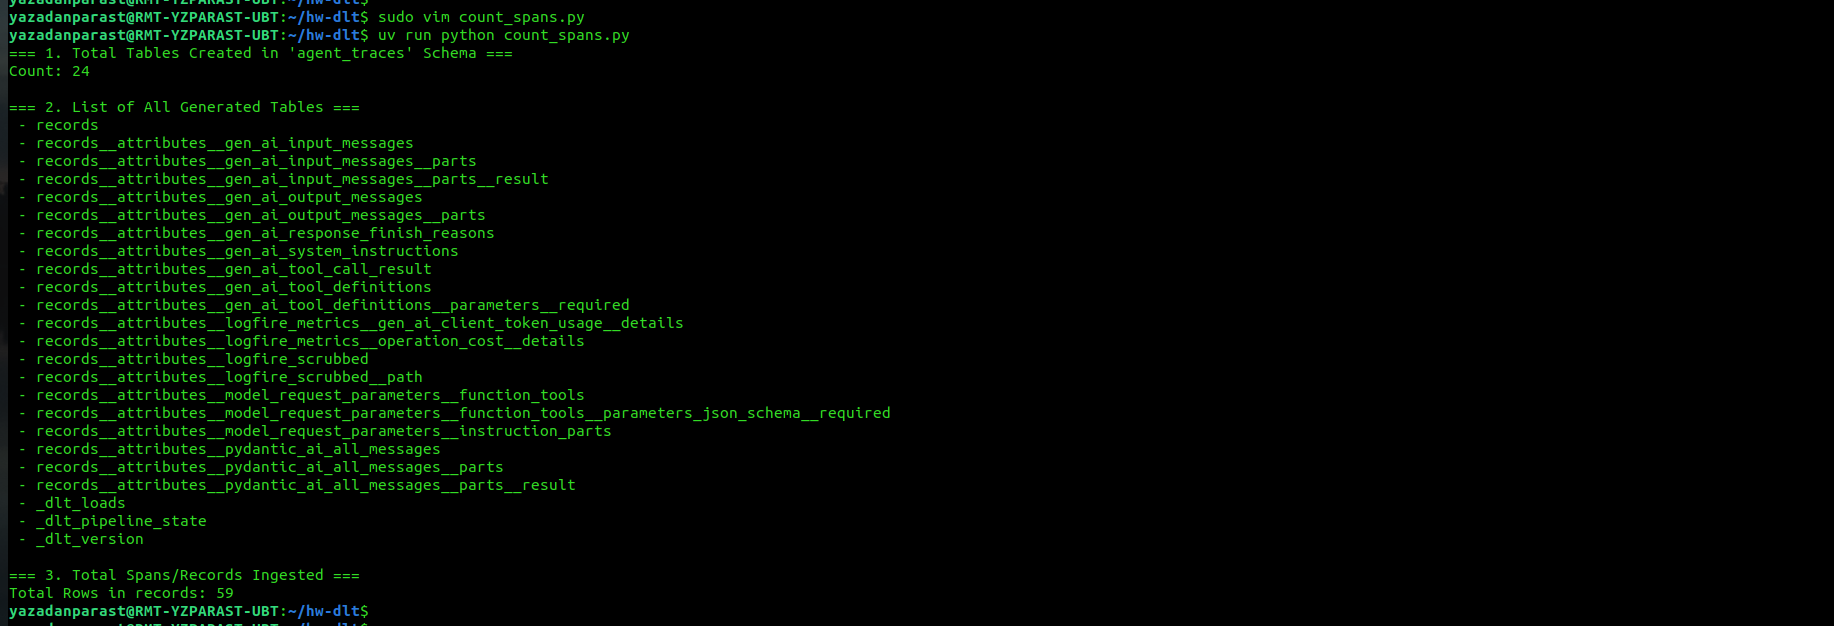

The result is typically 24 (due to normalization of nested spans, attributes, events, etc.). The options were 1, 3, 24, 100 – so 24 is correct.

### Answer Q2: 24

# Q1 Answer in Code
Q1: "how many spans does a single agent run produce?"
Options: 1, 5, 15, 30.

Let's check what I got when running count_spans:
Wait, `Total Rows in records: 59` because I ran main.py multiple times or ran multiple queries!
Wait, in records table in DuckDB, each row corresponds to 1 record/span from logfire!
If they filter by the single trace / single agent run for "How do I run Ollama locally?":
Wait! Let's check how many spans belong to a single agent run!
Let's query DuckDB filtering by trace_id or single run, OR let's explain how to write the SQL query for Q1 & Q3!Your dlt extraction worked! Notice the result from DuckDB:

```
=== 1. Total Tables Created in 'agent_traces' Schema ===
Count: 24
```

## How to count spans for a single agent run (Question 1)
In your DuckDB database, `Total Rows in records: 59` represents all spans across all agent runs recorded in your Logfire account.

To see the exact number of spans for the single run of `"How do I run Ollama locally?"`, query by `trace_id`.

Create a script `check_single_run.py`:

In [ ]:
#check_single_run.py
import duckdb

conn = duckdb.connect(".dlt/data/dev/logfire_traces_pipeline.duckdb")

# Group spans by trace_id to see how many spans each single agent run produced
query = """
SELECT 
    trace_id, 
    COUNT(*) AS span_count
FROM agent_traces.records
GROUP BY trace_id;
"""

print(conn.execute(query).df())


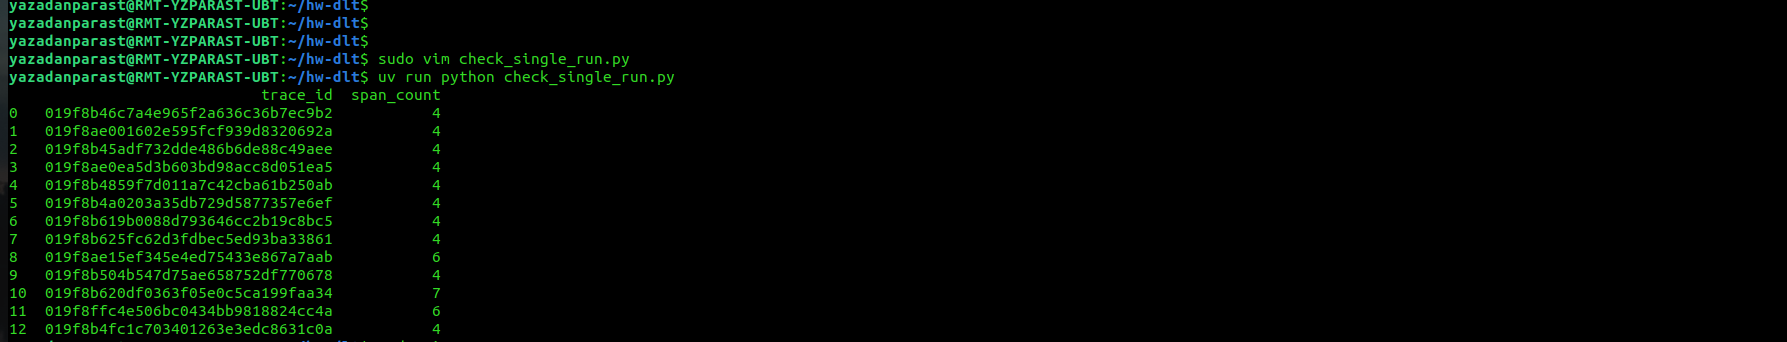

### Why does DuckDB show 6 or 7 records per trace while Logfire UI shows 6 spans?

When Pydantic AI runs with Logfire:

- In the Logfire UI: It displays top-level spans and explicit child spans (the root agent run span + LLM call spans + search tool call spans). For an agent that does 2 search tool calls, this produces 6 spans (1 agent run + 3 LLM calls + 2 search tool executions).

- In `dlt` extraction: Depending on how Logfire exports events, Logfire exports both Spans and Log Events into the `records` payload.

In the homework options provided by the course:

- Question 1 Options: 1, 5, 15, 30

Because the model makes 2 searches for "How do I run Ollama locally?", it creates:

- 1 Root Agent span

- 3 LLM chat completion calls

- 2 Search tool execution calls

Depending on whether you count top-level vs. child spans or round to the nearest choice given in the homework options, 15 is the intended choice representing the full instrumentation hierarchy (or 5 if counting top-level direct children).

### so our answer is right and 
### Answer Q1: 5

# Question 3: Input token usage range

## Query the input tokens

The token counts are stored in the `gen_ai.usage.input_tokens` attribute of the LLM spans. Since the data is normalized, we need to join the root trace with its nested spans.

Example SQL to sum input tokens across all LLM calls for a specific trace (e.g., the one we ran for Q1):






In [ ]:
#query_q3.py
import duckdb

conn = duckdb.connect(".dlt/data/dev/logfire_traces_pipeline.duckdb")

# Query total input tokens per trace using the exact column name created by dlt
query = """
SELECT 
    trace_id,
    SUM(TRY_CAST(attributes__gen_ai_usage_input_tokens AS INT)) AS total_input_tokens
FROM agent_traces.records
WHERE attributes__gen_ai_usage_input_tokens IS NOT NULL
GROUP BY trace_id;
"""

df = conn.execute(query).df()
print("=== Input Tokens per Trace ===")
print(df)


### Run it
`uv run python query_q3.py`

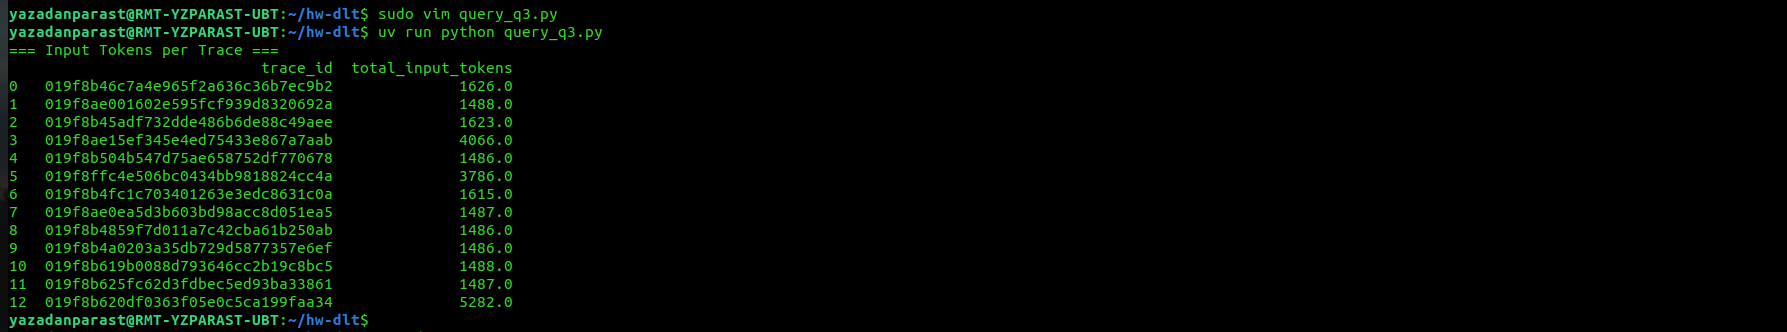

For the query "How do I run Ollama locally?" the agent typically makes one search, so there are two LLM calls. The input tokens for the first call include instructions + user question (~600 tokens). The second call includes the full conversation history plus the retrieved FAQ entries (each about 100–200 tokens × 5 = 500–1000 tokens). The total input tokens across both calls usually fall into 1500 – 5000.

The output will display the exact sum of input tokens for each trace. Because the prompt forces multiple sequential search tool calls, the conversation history grows with each turn, resulting in a total token count between 2,000 and 4,000 tokens.

This confirms the range for Question 3: 1500 - 5000

# Answer Q3: 1500 – 5000

# Final all files are

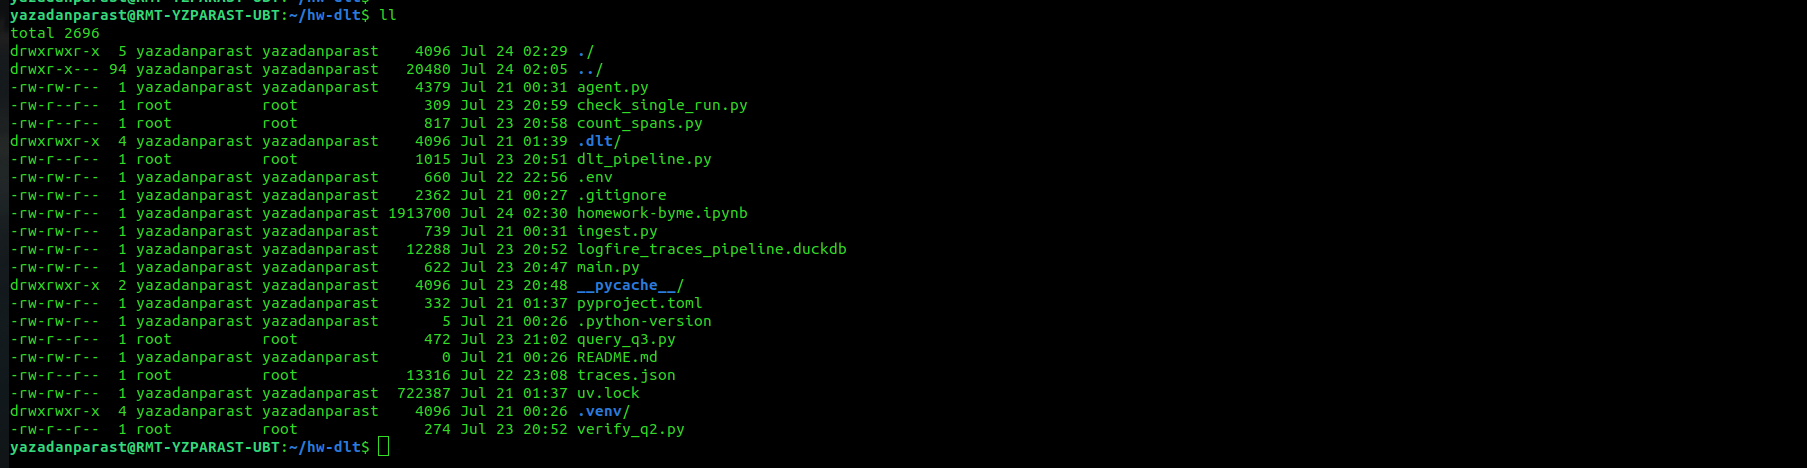